# Bayesian Inference: Explained by Coin Flipping

### Septemebr 22, 2026
#### This nifty experiment you can try without a computer

Get any regular coin and a pad of paper. 

We're going to flip a coin 100 times. 

The experiment as defined below has a predetermined set of heads and tails for sake of writing the report. 

What we're going to do test whether or not getting a heads or tails on one flip determines the probability of a heads or tails in the next. 





At the end of your coin flips, I want you to count how many heads and how many tails. 

And you must also keep the order of heads or tails.

When you’re done look at the probability of that exact order of heads or tails as determined by the immediate previous flip.

#### **Have Fun.**

And when you're done with your experiment, don't forget to share your order and how it got you to the results you have. 

In [1]:
%pip install scipy numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


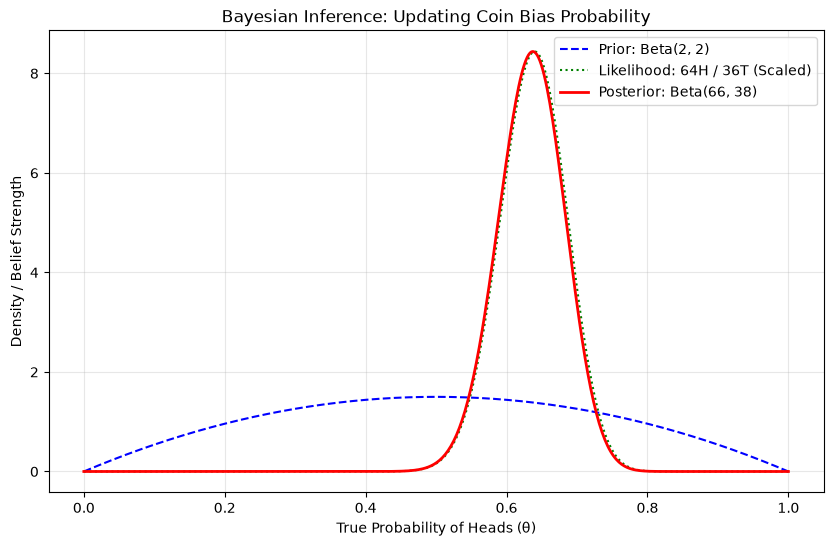

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# 1. Define the experiment data in trials and results

# n stands for “number” or “numeric”

n_trials = 100
n_heads = 64
n_tails = n_trials - n_heads

# 2. Define Prior parameters: Beta(2, 2)
# a stands for “alpha”
# b stands for “beta”

a_prior = 2
b_prior = 2

# 3. Calculate Posterior parameters: Beta(alpha + heads, beta + tails)

# Posterior parameters are parameters that change after a trial is completed 

a_posterior = a_prior + n_heads
b_posterior = b_prior + n_tails

# 4. Generate the range of possible coin bias values (theta from 0 to 1)

theta = np.linspace(0, 1, 500)

# Calculate the Probability Density Functions (PDF)

# A PDF, in this sense, is a function that describes the probability of a continuous random variable to take on a value

# A continuous random variable, much like it sounds, is an undefined variable that could take on any value within a set interval

prior_pdf = beta.pdf(theta, a_prior, b_prior)
posterior_pdf = beta.pdf(theta, a_posterior, b_posterior)

# The Binomial likelihood normalized so it scales visually with the PDFs

likelihood = binom.pmf(n_heads, n_trials, theta)
likelihood_normalized = likelihood * (np.max(posterior_pdf) / np.max(likelihood))

# 5. Plot the distributions
plt.figure(figsize=(10, 6))
plt.plot(theta, prior_pdf, label=f'Prior: Beta({a_prior}, {b_prior})', color='blue', linestyle='--')
plt.plot(theta, likelihood_normalized, label=f'Likelihood: {n_heads}H / {n_tails}T (Scaled)', color='green', linestyle=':')
plt.plot(theta, posterior_pdf, label=f'Posterior: Beta({a_posterior}, {b_posterior})', color='red', linewidth=2)

# Polish the chart
plt.title('Bayesian Inference: Updating Coin Bias Probability')
plt.xlabel('True Probability of Heads (θ)')
plt.ylabel('Density / Belief Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()